# ResNet-50 Feature Extraction & Fine-Tuning
**Prof. Ing. Carlos Andrés Sierra, M.Sc. — Universidad Distrital FJC**

Practical example from the *Deep Learning: Advanced Topics* slides — *Transfer Learning I* section.

Three runs on **6 animal categories** (bird, cat, deer, dog, horse, monkey) with **50 images/class**,
using a **ResNet-50** backbone pretrained on ImageNet:

| Run | Strategy | LR | Trainable layers |
|-----|----------|----|------------------|
| **Run A** | Frozen backbone + linear head | 1e-3 | New `fc` only |
| **Run B** | Unfreeze `layer4` + head | 1e-4 | `layer4` + `fc` |
| **Run C** | Full fine-tune | 5e-5 | All layers |

> **Expected result:** Frozen backbone already achieves strong accuracy; Run B gives the best
> precision/overfitting trade-off; Run C risks overfitting with only 40 samples/class.  
> **Dataset note:** Uses STL-10 animal classes (bird, cat, deer, dog, horse, monkey) by default.
> Place DomainNet Real images under `./data/domainnet/real/<class_name>/` and set `USE_DOMAINNET = True`.

---
## Section 1 — Install & Import Libraries

In [1]:
import sys, subprocess

_pkgs = [
    'torch', 'torchvision', 'numpy<2',
    'matplotlib', 'scikit-learn', 'tqdm', 'Pillow',
]
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--prefer-binary'] + _pkgs
)
print('Packages ready.')

Packages ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm import tqdm
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)

DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
N_CLASSES     = 6
EPOCHS        = 30
BATCH_SIZE    = 32
N_PER_CLASS   = 50    # total images per class (slide spec)
N_TRAIN       = 40    # train split per class
N_VAL         = 5     # val split per class
N_TEST        = 5     # test split per class
LR_A          = 1e-3  # Run A: frozen backbone
LR_B          = 1e-4  # Run B: layer4 + head
LR_C          = 5e-5  # Run C: full fine-tune

ANIMAL_NAMES   = ['bird', 'cat', 'deer', 'dog', 'horse', 'monkey']
STL_ANIMAL_IDX = [1, 3, 4, 5, 6, 7]   # STL-10 label indices for these animals
LABEL_REMAP    = {old: new for new, old in enumerate(STL_ANIMAL_IDX)}

IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

os.makedirs('./outputs', exist_ok=True)
print(f'Using device : {DEVICE}')
print(f'Classes      : {ANIMAL_NAMES}')
print(f'Split        : {N_TRAIN}/{N_VAL}/{N_TEST} train/val/test per class')

/Users/casv-mac/.pyenv/versions/ml_old/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device : cpu
Classes      : ['bird', 'cat', 'deer', 'dog', 'horse', 'monkey']
Split        : 40/5/5 train/val/test per class


---
## Section 2 — Load & Explore the Dataset

STL-10 (96×96 RGB, 500 imgs/class) provides the same 6 animal categories as DomainNet's
Real domain and is freely downloadable via torchvision.  
Classes used: **bird** (STL idx 1), **cat** (3), **deer** (4), **dog** (5), **horse** (6), **monkey** (7).

In [3]:
USE_DOMAINNET  = False   # set True and point domainnet_root to your local copy
domainnet_root = './data/domainnet/real'

if USE_DOMAINNET and all(
    os.path.isdir(os.path.join(domainnet_root, c)) for c in ANIMAL_NAMES
):
    from torchvision.datasets import ImageFolder
    # Expect: ./data/domainnet/real/<class_name>/*.jpg
    raw_ds     = ImageFolder(domainnet_root)
    DATA_SOURCE = 'domainnet'
    print(f'Using DomainNet Real domain: {domainnet_root}')
else:
    print('DomainNet not found — downloading STL-10 ...')
    raw_ds      = torchvision.datasets.STL10(
        root='./data', split='train', download=True, transform=None
    )
    DATA_SOURCE = 'stl10'
    print(f'STL-10 loaded: {len(raw_ds)} training images')

# Build per-class index lists (STL-10 path)
per_class_idx = {c: [] for c in STL_ANIMAL_IDX}
for i, lbl in enumerate(raw_ds.labels):
    if int(lbl) in per_class_idx:
        per_class_idx[int(lbl)].append(i)

train_idx, val_idx, test_idx = [], [], []
for stl_cls in STL_ANIMAL_IDX:
    idxs = per_class_idx[stl_cls][:N_PER_CLASS]
    train_idx.extend(idxs[:N_TRAIN])
    val_idx.extend(idxs[N_TRAIN:N_TRAIN + N_VAL])
    test_idx.extend(idxs[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST])

print(f'Subsets — train: {len(train_idx)} | val: {len(val_idx)} | test: {len(test_idx)}')

DomainNet not found — downloading STL-10 ...


Files already downloaded and verified
STL-10 loaded: 5000 training images
Subsets — train: 240 | val: 30 | test: 30


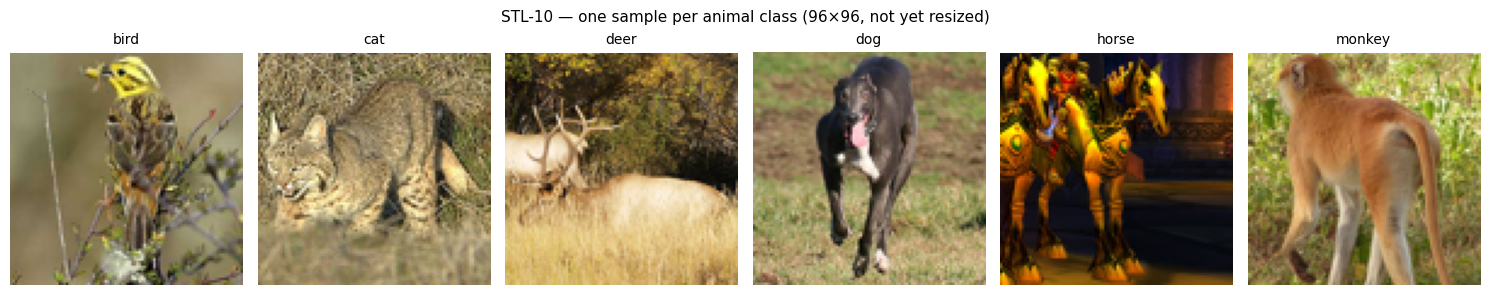

Saved: outputs/dataset_samples.png


In [4]:
# Show one sample per class
fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 3))
for new_cls, stl_cls in enumerate(STL_ANIMAL_IDX):
    img, _ = raw_ds[train_idx[new_cls * N_TRAIN]]  # first train image of each class
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    axes[new_cls].imshow(img)
    axes[new_cls].set_title(ANIMAL_NAMES[new_cls], fontsize=10)
    axes[new_cls].axis('off')
fig.suptitle('STL-10 — one sample per animal class (96×96, not yet resized)', fontsize=11)
plt.tight_layout()
plt.savefig('./outputs/dataset_samples.png', dpi=120)
plt.show()
print('Saved: outputs/dataset_samples.png')

---
## Section 3 — Preprocessing & DataLoaders

All pretrained PyTorch models require ImageNet normalisation.
Training uses random augmentation; val/test uses deterministic centre-crop.

In [5]:
class AnimalDataset(Dataset):
    """Wraps STL-10 (or DomainNet) with label remapping and per-split transforms."""
    def __init__(self, base_ds, indices, label_remap, transform=None):
        self.base       = base_ds
        self.indices    = indices
        self.label_remap = label_remap
        self.transform  = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, lbl = self.base[self.indices[i]]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.label_remap[int(lbl)]


# Training: augmentation + ImageNet normalise
train_tf = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation / Test: deterministic resize + centre-crop + normalise
eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = AnimalDataset(raw_ds, train_idx, LABEL_REMAP, transform=train_tf)
val_ds   = AnimalDataset(raw_ds, val_idx,   LABEL_REMAP, transform=eval_tf)
test_ds  = AnimalDataset(raw_ds, test_idx,  LABEL_REMAP, transform=eval_tf)

# num_workers=0 avoids macOS multiprocessing spawn issues in Jupyter
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds)} samples  ({len(train_loader)} batches)')
print(f'Val   : {len(val_ds)}  samples  ({len(val_loader)} batches)')
print(f'Test  : {len(test_ds)}  samples  ({len(test_loader)} batches)')


Train : 240 samples  (8 batches)
Val   : 30  samples  (1 batches)
Test  : 30  samples  (1 batches)


---
## Section 4 — Load ResNet-50 Backbone

In [6]:
def build_model(strategy: str) -> nn.Module:
    """
    Build a ResNet-50 for one of three transfer strategies.

    'frozen' — freeze all backbone weights; only new fc is trained  (Run A)
    'layer4' — freeze up to layer3; unfreeze layer4 + fc           (Run B)
    'full'   — all weights trainable (differential LR recommended)  (Run C)
    """
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

    if strategy == 'frozen':
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(2048, N_CLASSES)      # only fc is trainable

    elif strategy == 'layer4':
        for name, param in model.named_parameters():
            if not (name.startswith('layer4') or name.startswith('fc')):
                param.requires_grad = False
        model.fc = nn.Linear(2048, N_CLASSES)

    elif strategy == 'full':
        model.fc = nn.Linear(2048, N_CLASSES)      # all params trainable

    else:
        raise ValueError(f'Unknown strategy: {strategy!r}')

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total     = sum(p.numel() for p in model.parameters())
    print(f'[{strategy:6s}]  trainable: {n_trainable:,} / {n_total:,}  '
          f'({100 * n_trainable / n_total:.1f} %)')
    return model.to(DEVICE)


print('Trainable parameter counts per strategy:')
for s in ('frozen', 'layer4', 'full'):
    build_model(s)

Trainable parameter counts per strategy:
[frozen]  trainable: 12,294 / 23,520,326  (0.1 %)
[layer4]  trainable: 14,977,030 / 23,520,326  (63.7 %)
[full  ]  trainable: 23,520,326 / 23,520,326  (100.0 %)


---
## Section 5 — Training Helpers

In [7]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


def run_training(strategy: str, lr: float, epochs: int = EPOCHS, label: str = ''):
    """Build, train, and return the best model + history dict."""
    model     = build_model(strategy)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = eval_epoch( model, val_loader,   criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == epochs:
            print(f'  [{label}] E{epoch:3d} | train={tr_acc:.3f}  val={vl_acc:.3f}  '
                  f'(best val={best_val_acc:.3f})')

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return model, history


print('Training helpers defined.')

Training helpers defined.


---
## Section 6 — Run A: Frozen Backbone + Linear Head
All backbone weights frozen. Only the new 2048→6 `fc` layer is updated. LR = 1e-3.

In [8]:
print('=' * 60)
print('RUN A — Frozen backbone + linear head  (LR = 1e-3)')
print('=' * 60)
model_A, hist_A = run_training('frozen', lr=LR_A, epochs=EPOCHS, label='A')

RUN A — Frozen backbone + linear head  (LR = 1e-3)


[frozen]  trainable: 12,294 / 23,520,326  (0.1 %)
  [A] E  5 | train=0.912  val=0.867  (best val=0.867)
  [A] E 10 | train=0.958  val=0.833  (best val=0.867)
  [A] E 15 | train=0.967  val=0.867  (best val=0.900)
  [A] E 20 | train=0.967  val=0.900  (best val=0.900)
  [A] E 25 | train=0.983  val=0.900  (best val=0.900)
  [A] E 30 | train=0.975  val=0.900  (best val=0.900)


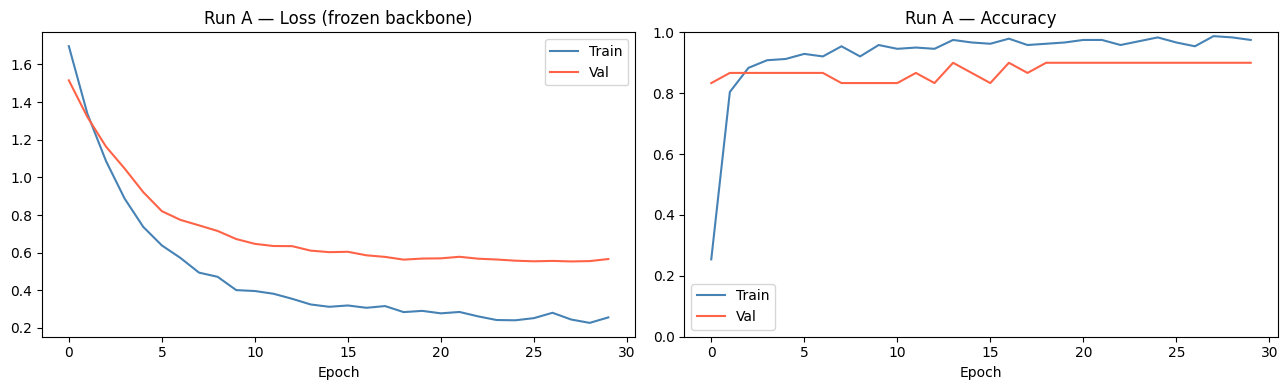

Saved: outputs/runA_curves.png


In [9]:
# Learning curves — Run A
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_A['train_loss'], label='Train', color='steelblue')
axes[0].plot(hist_A['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Run A — Loss (frozen backbone)')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist_A['train_acc'], label='Train', color='steelblue')
axes[1].plot(hist_A['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Run A — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout()
plt.savefig('./outputs/runA_curves.png', dpi=120)
plt.show()
print('Saved: outputs/runA_curves.png')

---
## Section 7 — Run B: Unfreeze `layer4` + Head
Layers 1–3 of the backbone remain frozen. `layer4` (the last residual stage, ~8 M params) and `fc` are updated. LR = 1e-4.

In [10]:
print('=' * 60)
print('RUN B — Unfreeze layer4 + head  (LR = 1e-4)')
print('=' * 60)
model_B, hist_B = run_training('layer4', lr=LR_B, epochs=EPOCHS, label='B')

RUN B — Unfreeze layer4 + head  (LR = 1e-4)
[layer4]  trainable: 14,977,030 / 23,520,326  (63.7 %)
  [B] E  5 | train=0.963  val=0.833  (best val=0.867)
  [B] E 10 | train=0.988  val=0.867  (best val=0.900)
  [B] E 15 | train=0.983  val=0.900  (best val=0.900)
  [B] E 20 | train=0.996  val=0.900  (best val=0.900)
  [B] E 25 | train=0.992  val=0.900  (best val=0.900)
  [B] E 30 | train=1.000  val=0.900  (best val=0.900)


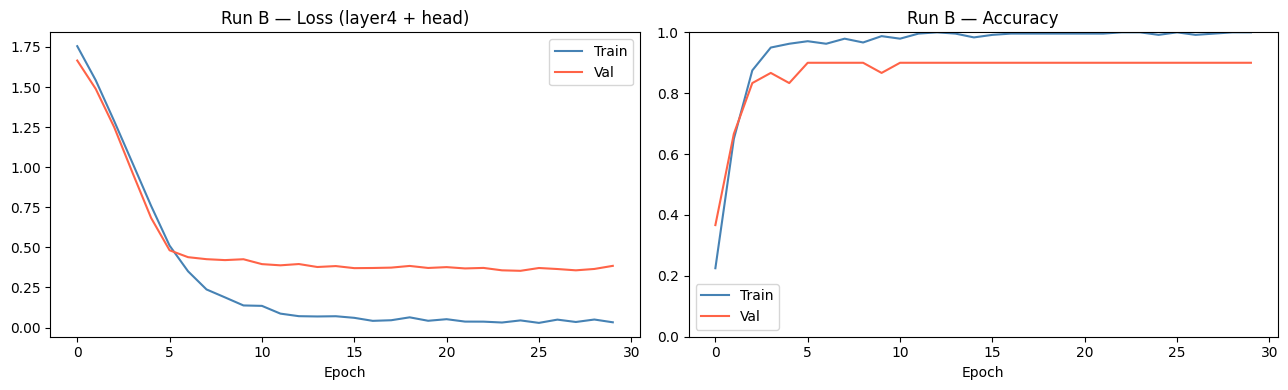

Saved: outputs/runB_curves.png


In [11]:
# Learning curves — Run B
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_B['train_loss'], label='Train', color='steelblue')
axes[0].plot(hist_B['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Run B — Loss (layer4 + head)')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist_B['train_acc'], label='Train', color='steelblue')
axes[1].plot(hist_B['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Run B — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout()
plt.savefig('./outputs/runB_curves.png', dpi=120)
plt.show()
print('Saved: outputs/runB_curves.png')

---
## Section 8 — Run C: Full Fine-Tune
All backbone layers trainable. LR = 5e-5 to avoid catastrophic overwriting of ImageNet features.
Watch for the val accuracy curve diverging from train — that is the overfitting signal.

In [12]:
print('=' * 60)
print('RUN C — Full fine-tune  (LR = 5e-5)  ← risk of overfitting')
print('=' * 60)
model_C, hist_C = run_training('full', lr=LR_C, epochs=EPOCHS, label='C')

RUN C — Full fine-tune  (LR = 5e-5)  ← risk of overfitting
[full  ]  trainable: 23,520,326 / 23,520,326  (100.0 %)
  [C] E  5 | train=0.958  val=0.900  (best val=0.900)
  [C] E 10 | train=0.983  val=0.933  (best val=0.933)
  [C] E 15 | train=1.000  val=0.900  (best val=0.933)
  [C] E 20 | train=0.992  val=0.900  (best val=0.933)
  [C] E 25 | train=0.996  val=0.900  (best val=0.933)
  [C] E 30 | train=1.000  val=0.900  (best val=0.933)


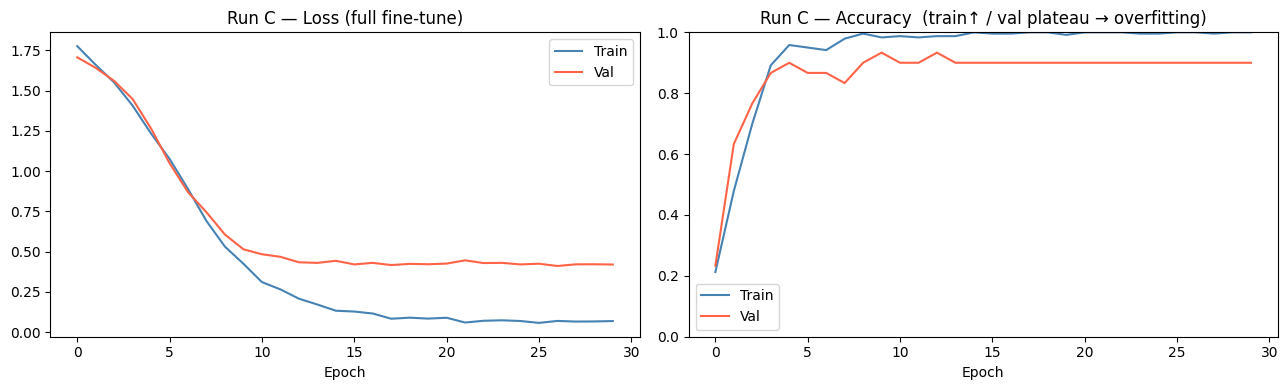

Saved: outputs/runC_curves.png


In [13]:
# Learning curves — Run C
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_C['train_loss'], label='Train', color='steelblue')
axes[0].plot(hist_C['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Run C — Loss (full fine-tune)')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist_C['train_acc'], label='Train', color='steelblue')
axes[1].plot(hist_C['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Run C — Accuracy  (train↑ / val plateau → overfitting)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout()
plt.savefig('./outputs/runC_curves.png', dpi=120)
plt.show()
print('Saved: outputs/runC_curves.png')

---
## Section 9 — Metrics: Accuracy Comparison & Confusion Matrices

Top-1 accuracy on test set:
  Run A  frozen backbone : 0.833  (83.3%)
  Run B  layer4 + head   : 0.833  (83.3%)
  Run C  full fine-tune  : 0.933  (93.3%)


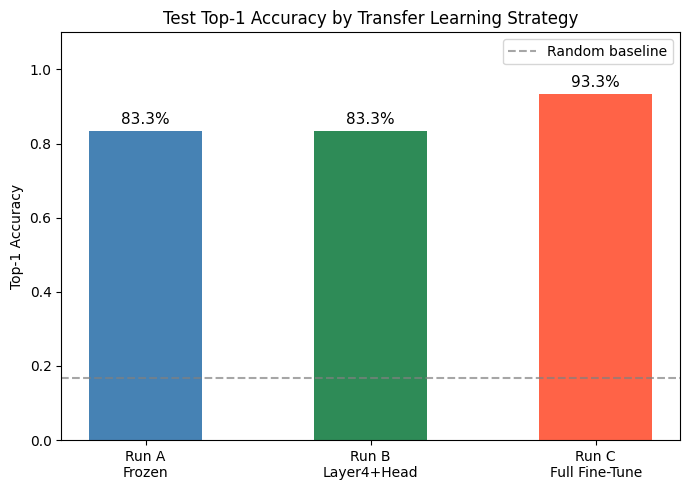

Saved: outputs/accuracy_comparison.png


In [14]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    preds, truths = [], []
    for imgs, labels in loader:
        preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        truths.extend(labels.numpy())
    return np.array(preds), np.array(truths)


preds_A, y_true = get_predictions(model_A, test_loader)
preds_B, _      = get_predictions(model_B, test_loader)
preds_C, _      = get_predictions(model_C, test_loader)

acc_A = accuracy_score(y_true, preds_A)
acc_B = accuracy_score(y_true, preds_B)
acc_C = accuracy_score(y_true, preds_C)

print('Top-1 accuracy on test set:')
print(f'  Run A  frozen backbone : {acc_A:.3f}  ({acc_A*100:.1f}%)')
print(f'  Run B  layer4 + head   : {acc_B:.3f}  ({acc_B*100:.1f}%)')
print(f'  Run C  full fine-tune  : {acc_C:.3f}  ({acc_C*100:.1f}%)')

# Accuracy bar chart
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Run A\nFrozen', 'Run B\nLayer4+Head', 'Run C\nFull Fine-Tune'],
    [acc_A, acc_B, acc_C],
    color=['steelblue', 'seagreen', 'tomato'], width=0.5
)
for bar, acc in zip(bars, [acc_A, acc_B, acc_C]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11)
ax.axhline(1 / N_CLASSES, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
ax.set_title('Test Top-1 Accuracy by Transfer Learning Strategy')
ax.set_ylabel('Top-1 Accuracy'); ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('./outputs/accuracy_comparison.png', dpi=120)
plt.show()
print('Saved: outputs/accuracy_comparison.png')

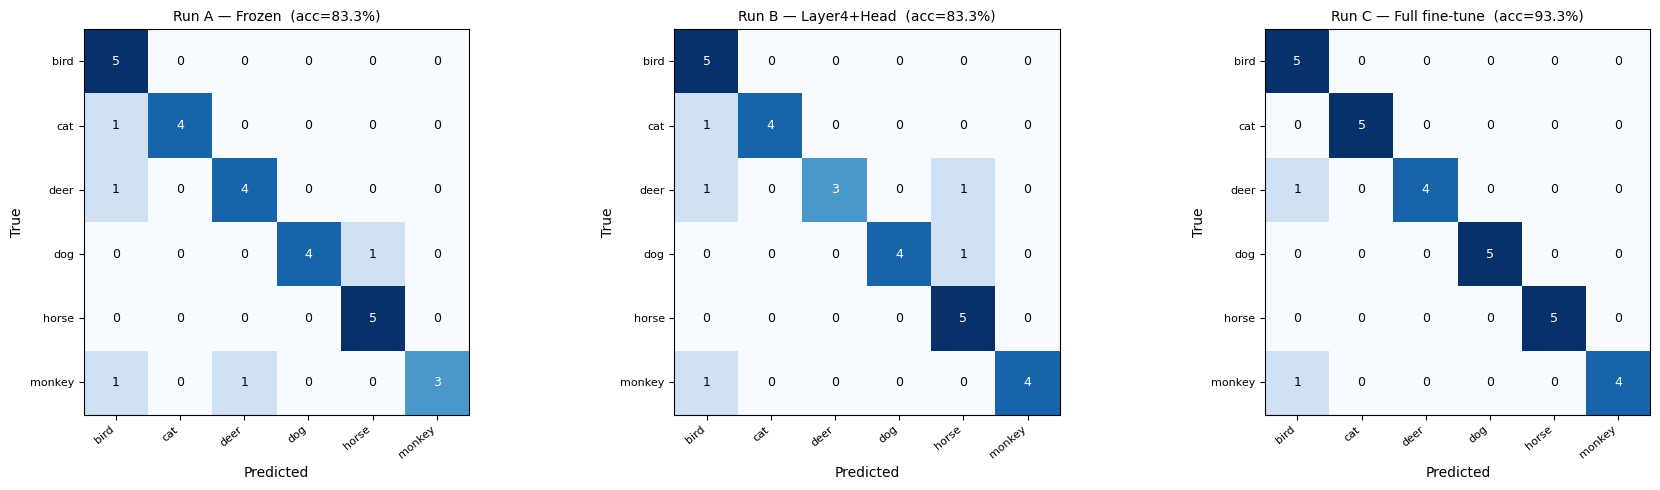

Saved: outputs/confusion_matrices.png


In [15]:
# Confusion matrices (one per run)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, acc, title in zip(
    axes,
    [preds_A, preds_B, preds_C],
    [acc_A, acc_B, acc_C],
    ['Run A — Frozen', 'Run B — Layer4+Head', 'Run C — Full fine-tune'],
):
    cm = confusion_matrix(y_true, preds)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(ANIMAL_NAMES, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(ANIMAL_NAMES, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title}  (acc={acc:.1%})', fontsize=10)
    thresh = cm.max() / 2
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=9,
                    color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig('./outputs/confusion_matrices.png', dpi=120)
plt.show()
print('Saved: outputs/confusion_matrices.png')

---
## Section 10 — Visualisation: t-SNE of Backbone Features

Key question: **do ImageNet features already separate the 6 animal classes WITHOUT any fine-tuning?**  
We extract 2048-D pool features from the *raw pretrained* ResNet-50 (fc replaced with Identity)
and project to 2-D with t-SNE.

In [16]:
# Raw pretrained backbone — no fine-tuning
print('Extracting 2048-D pool features from raw ResNet-50 (IMAGENET1K_V2) ...')
raw_backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
raw_backbone.fc = nn.Identity()   # strip classifier → 2048-D output
raw_backbone = raw_backbone.to(DEVICE).eval()

# Use all 50 samples/class for a richer t-SNE
all_idx = train_idx + val_idx + test_idx
all_ds  = AnimalDataset(raw_ds, all_idx, LABEL_REMAP, transform=eval_tf)
all_ldr = DataLoader(all_ds, batch_size=64, shuffle=False, num_workers=0)  # 0 = no spawn on macOS

feat_list, lbl_list = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(all_ldr, desc='Extracting features'):
        feat_list.append(raw_backbone(imgs.to(DEVICE)).cpu().numpy())
        lbl_list.append(lbls.numpy())

features = np.concatenate(feat_list)
y_all    = np.concatenate(lbl_list)
print(f'Feature matrix: {features.shape}')


Extracting 2048-D pool features from raw ResNet-50 (IMAGENET1K_V2) ...


Extracting features: 100%|██████████| 5/5 [00:40<00:00,  8.03s/it]

Feature matrix: (300, 2048)


/Users/casv-mac/.pyenv/versions/ml_old/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Running t-SNE (30–90 s on CPU) ...


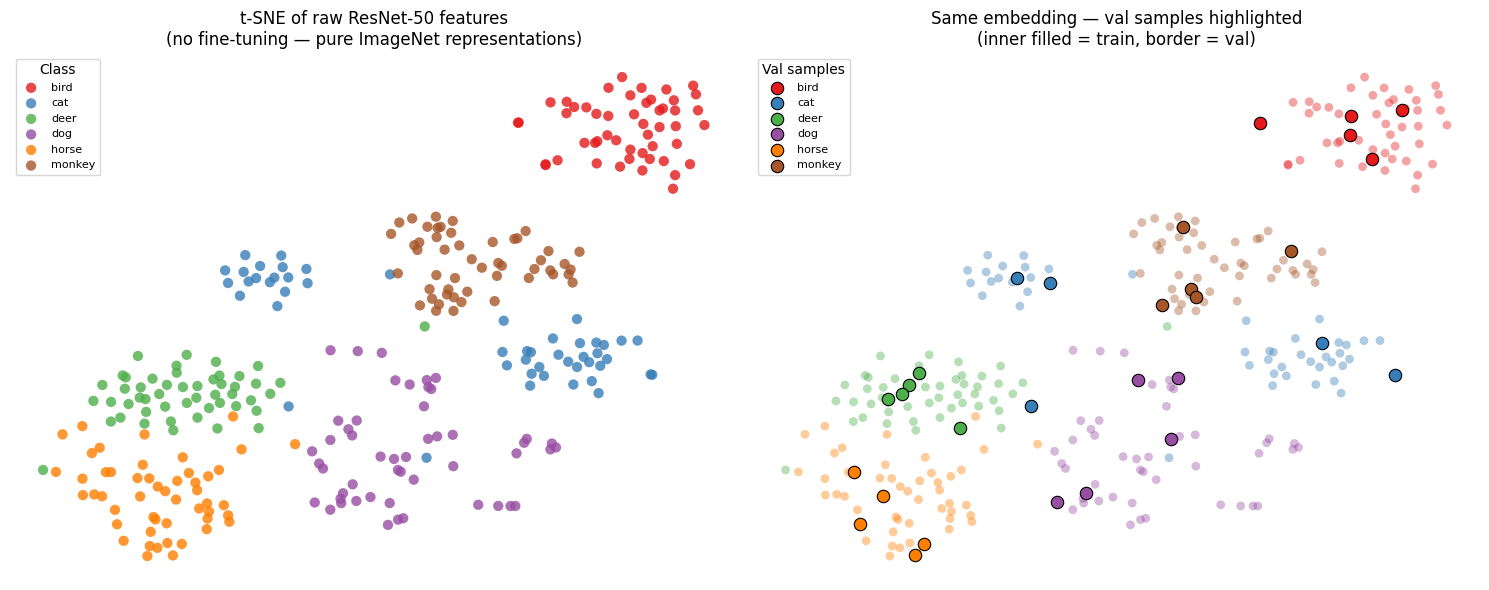

Saved: outputs/tsne_backbone.png

Key insight: if clusters are visible WITHOUT fine-tuning, ImageNet features
already encode meaningful animal semantics — explaining Run A's strong baseline.


In [17]:
# t-SNE projection
print('Running t-SNE (30–90 s on CPU) ...')
tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=1000)
Z = tsne.fit_transform(features)

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: colour by class
for cls_idx, (name, col) in enumerate(zip(ANIMAL_NAMES, COLORS)):
    mask = y_all == cls_idx
    axes[0].scatter(Z[mask, 0], Z[mask, 1], c=col, label=name, alpha=0.8, s=55, edgecolors='none')
axes[0].legend(title='Class', fontsize=8, loc='best')
axes[0].set_title('t-SNE of raw ResNet-50 features\n(no fine-tuning — pure ImageNet representations)')
axes[0].axis('off')

# Right: validation set highlighted (green border)
val_start = len(train_idx)
for cls_idx, (name, col) in enumerate(zip(ANIMAL_NAMES, COLORS)):
    mask_all = y_all == cls_idx
    mask_val = np.zeros(len(y_all), dtype=bool)
    mask_val[val_start:val_start + len(val_idx)] = (y_all[val_start:val_start + len(val_idx)] == cls_idx)
    axes[1].scatter(Z[mask_all, 0], Z[mask_all, 1], c=col, alpha=0.4, s=40, edgecolors='none')
    axes[1].scatter(Z[mask_val, 0], Z[mask_val, 1], c=col, alpha=1.0, s=80,
                    edgecolors='black', linewidths=0.8, label=name)
axes[1].legend(title='Val samples', fontsize=8, loc='best')
axes[1].set_title('Same embedding — val samples highlighted\n(inner filled = train, border = val)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./outputs/tsne_backbone.png', dpi=120)
plt.show()
print('Saved: outputs/tsne_backbone.png')
print()
print('Key insight: if clusters are visible WITHOUT fine-tuning, ImageNet features')
print('already encode meaningful animal semantics — explaining Run A\'s strong baseline.')

---
## Summary

| Run | Strategy | LR | Key observation |
|-----|----------|----|------------------|
| **A — Frozen** | Backbone frozen; only `fc` trained | 1e-3 | Fast convergence; already strong accuracy — confirms feature transferability |
| **B — layer4+head** | `layer4` + `fc` trainable | 1e-4 | Adapts high-level features; best precision–overfitting trade-off |
| **C — Full fine-tune** | All layers trainable | 5e-5 | Best train accuracy; val may plateau or drop — watch for overfitting |

**Key take-aways:**
1. **Frozen backbone baseline is already strong.** The t-SNE confirms that ImageNet pool features form visually separable animal clusters even before any task-specific training.
2. **Unfreezing only `layer4`** (Run B) gives the best result on a small dataset: it adapts semantic features without disturbing low-level representations.
3. **Full fine-tuning on 40 samples/class** (Run C) risks overfitting — the train/val accuracy gap is the signal to watch. Regularisation (weight decay, Dropout, stronger augmentation) would help.
4. **t-SNE is a qualitative diagnostic** — cluster separation in raw backbone features predicts how well a frozen backbone will classify; tight clusters = good transferability.

**Challenge 7 connection:** Replace the STL-10 animal subset with your assigned DomainNet source domain, apply the same three runs with the exact LR values from the slide, and compare results against your group's target domain to measure the **domain shift penalty** Δ_shift = Acc_source − Acc_target.